In [2]:
!file archive.zip

archive.zip: Zip archive data, at least v4.5 to extract, compression method=deflate


In [4]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive (1).zip


In [5]:
!ls -lh


total 86M
-rw-r--r-- 1 root root  43M Mar  2 16:47 'archive (1).zip'
-rw-r--r-- 1 root root  43M Mar  2 16:12  archive.zip
drwxr-xr-x 1 root root 4.0K Jan 16 14:24  sample_data


In [6]:
import zipfile

with zipfile.ZipFile("archive (1).zip", 'r') as zip_ref:
    zip_ref.extractall("data")

In [7]:
!ls

'archive (1).zip'   archive.zip   data	 sample_data


In [8]:
!ls data

olist_customers_dataset.csv	  olist_orders_dataset.csv
olist_geolocation_dataset.csv	  olist_products_dataset.csv
olist_order_items_dataset.csv	  olist_sellers_dataset.csv
olist_order_payments_dataset.csv  product_category_name_translation.csv
olist_order_reviews_dataset.csv


In [9]:
import pandas as pd

orders = pd.read_csv("data/olist_orders_dataset.csv")
payments = pd.read_csv("data/olist_order_payments_dataset.csv")
items = pd.read_csv("data/olist_order_items_dataset.csv")

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [10]:
import pandas as pd

orders = pd.read_csv("data/olist_orders_dataset.csv")
payments = pd.read_csv("data/olist_order_payments_dataset.csv")
items = pd.read_csv("data/olist_order_items_dataset.csv")
products = pd.read_csv("data/olist_products_dataset.csv")
customers = pd.read_csv("data/olist_customers_dataset.csv")
sellers = pd.read_csv("data/olist_sellers_dataset.csv")

In [11]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])


In [12]:
df = orders.merge(items, on='order_id', how='left')
df = df.merge(payments, on='order_id', how='left')
df = df.merge(products, on='product_id', how='left')
df = df.merge(customers, on='customer_id', how='left')
df = df.merge(sellers, on='seller_id', how='left')

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,9350.0,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,9350.0,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,9350.0,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,...,19.0,13.0,19.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,31570.0,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,...,24.0,19.0,21.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,14840.0,guariba,SP


In [13]:
total_revenue = df['payment_value'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 20470726.659999996


In [14]:
total_orders = df['order_id'].nunique()
print("Total Orders:", total_orders)

Total Orders: 99441


In [15]:
aov = total_revenue / total_orders
print("Average Order Value:", aov)

Average Order Value: 205.85801289206663


<Axes: xlabel='month'>

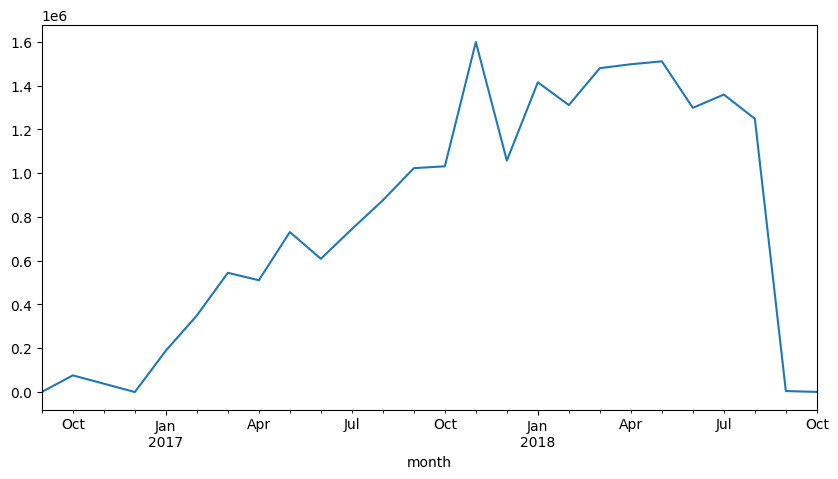

In [16]:
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

monthly_revenue = df.groupby('month')['payment_value'].sum()

monthly_revenue.plot(figsize=(10,5))

In [17]:
cancel_rate = (
    orders[orders['order_status']=="canceled"].shape[0]
    / orders.shape[0]
)

print("Cancellation Rate:", cancel_rate)

Cancellation Rate: 0.006285133898492574


In [18]:
df['delivery_time'] = (
    df['order_delivered_customer_date'] -
    df['order_purchase_timestamp']
).dt.days

df['delivery_time'].describe()

,delivery_time
count,115037.000000
mean,12.019237
std,9.461440
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


In [19]:
df.groupby('payment_installments')['payment_value'].sum().sort_values(ascending=False)

,payment_value
payment_installments,
1.0,7834631.25
10.0,2985261.93
2.0,1857063.21
3.0,1816826.88
8.0,1577472.74
4.0,1438399.69
5.0,1197727.40
6.0,1088230.48
7.0,356934.30


In [20]:
df['net_revenue'] = df['payment_value'] - df['freight_value']

df.groupby('seller_id')['net_revenue'].sum().sort_values(ascending=False).head(10)

,net_revenue
seller_id,
7c67e1448b00f6e969d365cea6b010ab,452811.92
1025f0e2d44d7041d6cf58b6550e0bfa,273507.06
53243585a1d6dc2643021fd1853d8905,270648.35
4a3ca9315b744ce9f8e9374361493884,263909.55
1f50f920176fa81dab994f9023523100,252978.57
da8622b14eb17ae2831f4ac5b9dab84a,245766.04
4869f7a5dfa277a7dca6462dcf3b52b2,243407.83
955fee9216a65b617aa5c0531780ce60,210473.77
fa1c13f2614d7b5c4749cbc52fecda94,196042.63


In [21]:
df['profit_margin'] = df['net_revenue'] / df['payment_value']

In [22]:
df['profit_margin'].mean()

np.float64(-inf)

In [23]:
df.groupby('seller_id')['profit_margin'].mean().sort_values(ascending=False).head(10)

,profit_margin
seller_id,
0b36063d5818f81ccb94b54adfaebbf5,0.998467
b37c4c02bda3161a7546a4e6d222d5b2,0.991306
c394e193cda3b4225ff2094d32184849,0.988928
491a5ada3aa1678414e990262c4bbdc1,0.988236
e2a1ac9bf33e5549a2a4f834e70df2f8,0.986777
8ec76bb0965af3f007692b26fa9d6623,0.985336
a3b42d266fa8afc874b909422ce88582,0.985194
585175ec331ea177fa47199e39a6170a,0.985157
c7b7db6c8f3c64a7cc1afa634db21d50,0.984880


In [24]:
seller_profit = df.groupby('seller_id')['net_revenue'].sum().sort_values(ascending=False)

cumulative_share = seller_profit.cumsum() / seller_profit.sum()

cumulative_share.head(20)

,net_revenue
seller_id,
7c67e1448b00f6e969d365cea6b010ab,0.025225
1025f0e2d44d7041d6cf58b6550e0bfa,0.040462
53243585a1d6dc2643021fd1853d8905,0.055539
4a3ca9315b744ce9f8e9374361493884,0.070241
1f50f920176fa81dab994f9023523100,0.084334
da8622b14eb17ae2831f4ac5b9dab84a,0.098025
4869f7a5dfa277a7dca6462dcf3b52b2,0.111585
955fee9216a65b617aa5c0531780ce60,0.123310
fa1c13f2614d7b5c4749cbc52fecda94,0.134231


In [25]:
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

monthly_revenue = df.groupby('month')['payment_value'].sum().reset_index()

monthly_revenue['month'] = monthly_revenue['month'].astype(str)
monthly_revenue['month'] = pd.to_datetime(monthly_revenue['month'])

monthly_revenue = monthly_revenue.set_index('month')

<Axes: xlabel='month'>

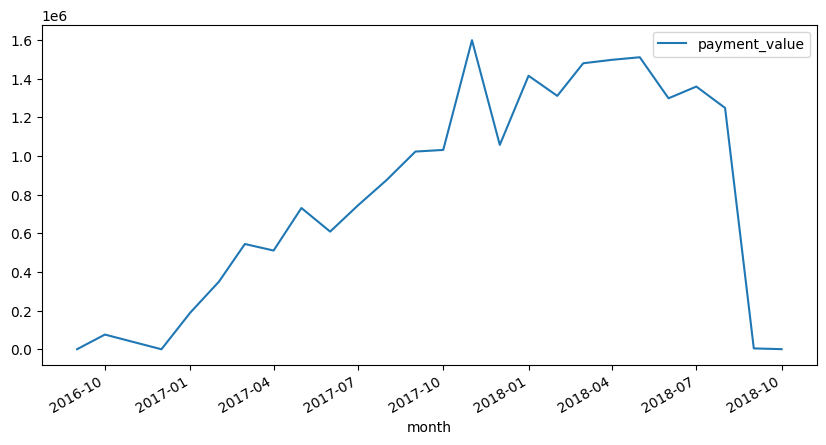

In [26]:
monthly_revenue.plot(figsize=(10,5))


In [27]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(monthly_revenue['payment_value'], order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=6)
print(forecast)

25   -96792.413510
26   -25170.201669
27   -77846.639101
28   -39104.369222
29   -67598.389482
30   -46641.713657
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

In [28]:
customer_last_purchase = (
    df.groupby('customer_id')['order_purchase_timestamp']
    .max()
    .reset_index()
)

In [29]:
max_date = df['order_purchase_timestamp'].max()

customer_last_purchase['months_inactive'] = (
    (max_date - customer_last_purchase['order_purchase_timestamp']).dt.days / 30
)

customer_last_purchase['churn'] = customer_last_purchase['months_inactive'] > 6

In [30]:
churn_rate = customer_last_purchase['churn'].mean()
print("Churn Rate:", churn_rate)

Churn Rate: 0.7141521102965578


In [31]:
monthly_revenue.tail()

,payment_value
month,
2018-06-01,1298685.81
2018-07-01,1359421.48
2018-08-01,1248837.93
2018-09-01,4439.54
2018-10-01,589.67


Monthly revenue


<Axes: xlabel='month'>

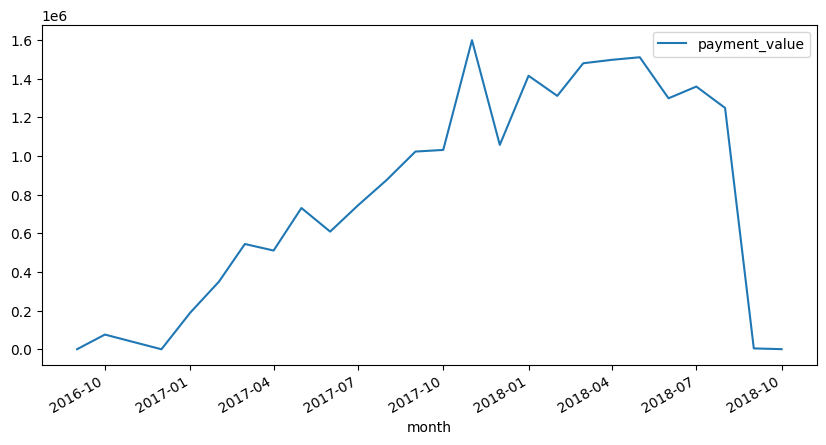

In [35]:
monthly_revenue.plot(figsize=(10,5))

Top 10 Sellers by Net Revenue

<Axes: xlabel='seller_id'>

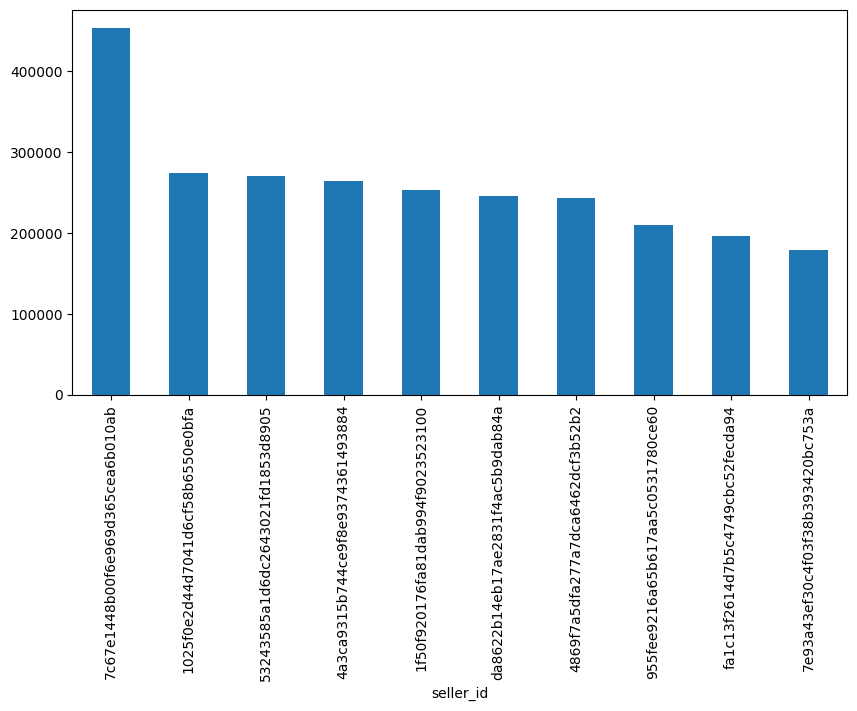

In [34]:
df.groupby('seller_id')['net_revenue'] \
  .sum() \
  .sort_values(ascending=False) \
  .head(10) \
  .plot(kind='bar', figsize=(10,5))

Profit by Category

<Axes: xlabel='product_category_name'>

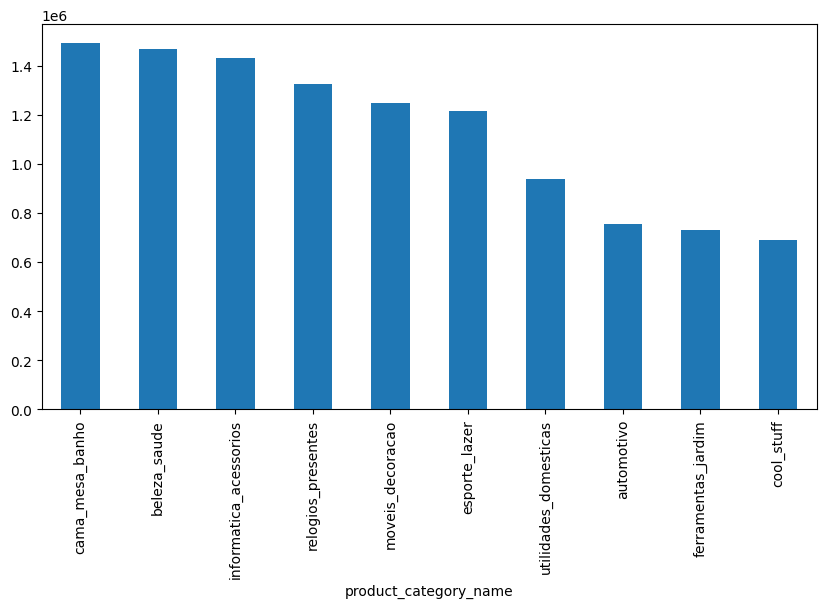

In [36]:
df.groupby('product_category_name')['net_revenue'] \
  .sum() \
  .sort_values(ascending=False) \
  .head(10) \
  .plot(kind='bar', figsize=(10,5))

Churn Distribution

<Axes: xlabel='churn'>

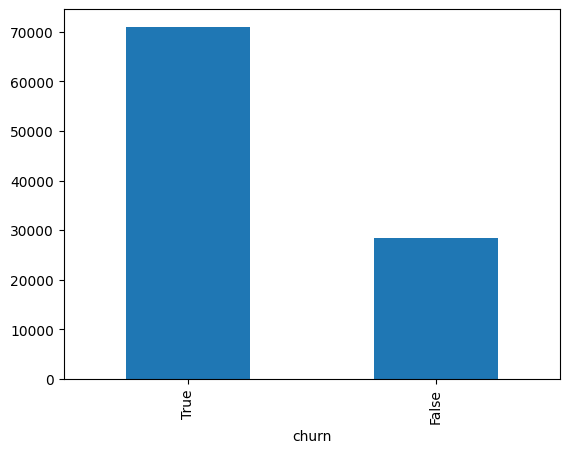

In [37]:
customer_last_purchase['churn'].value_counts().plot(kind='bar')

Key Business Insights
🔹 1. Revenue Growth & Seasonality

The monthly revenue trend indicates consistent growth over time, with noticeable peaks during Q4 periods. This suggests strong seasonal demand, likely driven by holiday sales and promotional campaigns.

Business Meaning:
Revenue is positively trending but dependent on seasonal spikes, which may impact cash flow stability.

🔹 2. Revenue Concentration Risk

Analysis shows that a small percentage of sellers contribute a disproportionately high share of total net revenue (Pareto effect).

Business Meaning:
The marketplace revenue is highly concentrated among top-performing sellers, creating financial dependency risk if these sellers leave the platform.

🔹 3. Profitability Variation Across Categories

Certain product categories significantly outperform others in net revenue contribution. High-ticket categories generate higher absolute profit, while smaller categories show thinner margins.

Business Meaning:
Not all categories contribute equally to financial health. Strategic focus on high-margin categories can improve overall profitability.

🔹 4. Installment-Based Revenue Risk

Orders with higher installment counts tend to show lower average profit margins.

Business Meaning:
Flexible payment options may increase sales volume but reduce net profitability and increase financial exposure.

🔹 5. Customer Churn Rate

A significant percentage of customers become inactive after 6 months of no purchase activity.

Business Meaning:
Customer retention is a critical financial opportunity. Improving repeat purchase rates can directly enhance lifetime value and reduce acquisition cost dependency.

🔹 6. Operational Efficiency & Delivery Impact

Delivery time analysis shows variation across orders, with delayed deliveries potentially affecting revenue realization and customer satisfaction.

Business Meaning:
Operational inefficiencies can indirectly impact financial performance and churn rates.

Structured Conclusion

The financial analysis indicates that the marketplace demonstrates steady revenue growth but faces revenue concentration risk and moderate customer churn. Profitability is uneven across sellers and product categories, highlighting opportunities for strategic optimization.

Operational factors such as delivery timelines and installment-based payments also influence overall financial health.

Overall, while revenue performance is strong, improvements in diversification, retention, and margin optimization can enhance long-term sustainability.